<a href="https://colab.research.google.com/github/Rini43/Asteroid_Diameter_Prediction/blob/main/Exit_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Asteroides Diameter Predictor

# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import joblib
import os

# Read the data

In [2]:
# filepath to the .excel file
# Load the dataset from the cloned GitHub repository

filepath = '/content/drive/MyDrive/Data/dataset.csv'
df_asteroid = pd.read_csv(filepath)
df_asteroid.head(20)

/tmp/ipykernel_2731/4088132661.py:5: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_asteroid = pd.read_csv(filepath)


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191
5,a0000006,2000006,6 Hebe,6,Hebe,NaN,N,N,5.80,185.180,...,2.191800e-06,1.122100e-05,1.300600e-05,7.392200e-06,3.306700e-09,4.438800e-10,2.875400e-05,2.344500e-06,MBA,0.41032
6,a0000007,2000007,7 Iris,7,Iris,NaN,N,N,5.60,199.830,...,2.582500e-06,2.641200e-05,2.707500e-05,7.014700e-06,2.469500e-09,3.370100e-10,2.662700e-05,1.699400e-06,MBA,0.38128
7,a0000008,2000008,8 Flora,8,Flora,NaN,N,N,6.50,147.491,...,3.240300e-06,2.432000e-05,2.664600e-05,1.209200e-05,2.668100e-09,4.746200e-10,4.018700e-05,1.876500e-06,MBA,0.54186
8,a0000009,2000009,9 Metis,9,Metis,NaN,N,N,6.30,190.000,...,2.007400e-06,2.417000e-05,2.600800e-05,1.036600e-05,3.470200e-09,5.192700e-10,3.870700e-05,2.614600e-06,MBA,0.44895
9,a0000010,2000010,10 Hygiea,10,Hygiea,NaN,N,N,5.50,407.120,...,2.173400e-06,2.855200e-05,3.023700e-05,1.124600e-05,7.699800e-09,5.847400e-10,6.482900e-05,6.724400e-06,MBA,0.53434


## EDA

In [3]:
# Identifying numerical and categorical data
df_asteroid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 45 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              958524 non-null  object 
 1   spkid           958524 non-null  int64  
 2   full_name       958524 non-null  object 
 3   pdes            958524 non-null  object 
 4   name            22064 non-null   object 
 5   prefix          18 non-null      object 
 6   neo             958520 non-null  object 
 7   pha             938603 non-null  object 
 8   H               952261 non-null  float64
 9   diameter        136209 non-null  float64
 10  albedo          135103 non-null  float64
 11  diameter_sigma  136081 non-null  float64
 12  orbit_id        958524 non-null  object 
 13  epoch           958524 non-null  float64
 14  epoch_mjd       958524 non-null  int64  
 15  epoch_cal       958524 non-null  float64
 16  equinox         958524 non-null  object 
 17  e         

In [4]:
# Identifying dataset size
df_asteroid.shape

(958524, 45)

In [5]:
# Statistical Summary
df_asteroid.describe()

,spkid,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,epoch_cal,e,a,...,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,rms
count,9.585240e+05,952261.000000,136209.000000,135103.000000,136081.000000,9.585240e+05,958524.000000,9.585240e+05,958524.000000,958524.000000,...,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.385980e+05,9.386020e+05,9.386020e+05,9.385980e+05,958522.000000
mean,3.810114e+06,16.906411,5.506429,0.130627,0.479184,2.458869e+06,58868.781950,2.019693e+07,0.156116,2.902143,...,1.982929e+01,1.168449e+00,5.310234e+00,1.370062e+06,1.369977e+06,2.131453e+01,5.060221e-02,4.312780e+08,8.525815e+04,0.561153
std,6.831541e+06,1.790405,9.425164,0.110323,0.782895,7.016716e+02,701.671573,1.930354e+04,0.092643,39.719503,...,2.903785e+03,1.282231e+02,1.333381e+03,9.158996e+08,9.158991e+08,7.197034e+03,9.814953e+00,2.953046e+11,2.767681e+07,2.745700
min,2.000001e+06,-1.100000,0.002500,0.001000,0.000500,2.425052e+06,25051.000000,1.927062e+07,0.000000,-14702.447872,...,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,0.000000
25%,2.239632e+06,16.100000,2.780000,0.053000,0.180000,2.459000e+06,59000.000000,2.020053e+07,0.092193,2.387835,...,1.462000e-07,6.095900e-06,3.619400e-05,5.755000e-05,2.573700e-05,2.340900e-08,2.768800e-09,1.110900e-04,1.794500e-05,0.518040
50%,2.479262e+06,16.900000,3.972000,0.079000,0.332000,2.459000e+06,59000.000000,2.020053e+07,0.145002,2.646969,...,2.271900e-07,8.688800e-06,6.642550e-05,1.047100e-04,4.900100e-05,4.359000e-08,4.638000e-09,2.230800e-04,3.501700e-05,0.566280
75%,3.752518e+06,17.714000,5.765000,0.190000,0.620000,2.459000e+06,59000.000000,2.020053e+07,0.200650,3.001932,...,6.583200e-07,1.591500e-05,1.609775e-04,3.114400e-04,1.718900e-04,1.196600e-07,1.124000e-08,8.139600e-04,9.775475e-05,0.613927
max,5.401723e+07,33.200000,939.400000,1.000000,140.000000,2.459000e+06,59000.000000,2.020053e+07,1.855356,33488.895955,...,1.015000e+06,5.533000e+04,1.199100e+06,8.845100e+11,8.845100e+11,5.509700e+06,7.698800e+03,2.853100e+14,1.910700e+10,2686.600000


In [6]:
df_asteroid.columns.tolist()

['id',
 'spkid',
 'full_name',
 'pdes',
 'name',
 'prefix',
 'neo',
 'pha',
 'H',
 'diameter',
 'albedo',
 'diameter_sigma',
 'orbit_id',
 'epoch',
 'epoch_mjd',
 'epoch_cal',
 'equinox',
 'e',
 'a',
 'q',
 'i',
 'om',
 'w',
 'ma',
 'ad',
 'n',
 'tp',
 'tp_cal',
 'per',
 'per_y',
 'moid',
 'moid_ld',
 'sigma_e',
 'sigma_a',
 'sigma_q',
 'sigma_i',
 'sigma_om',
 'sigma_w',
 'sigma_ma',
 'sigma_ad',
 'sigma_n',
 'sigma_tp',
 'sigma_per',
 'class',
 'rms']

In [7]:
df_asteroid.dtypes

,0
id,object
spkid,int64
full_name,object
pdes,object
name,object
prefix,object
neo,object
pha,object
H,float64
diameter,float64


### MIssing Values

In [8]:
# Trying to findout if there is any missing value present
df_asteroid.isna().sum()

,0
id,0
spkid,0
full_name,0
pdes,0
name,936460
prefix,958506
neo,4
pha,19921
H,6263
diameter,822315


### Duplicated Columns

In [9]:
df_asteroid.duplicated().sum()

np.int64(0)

In [10]:
df_asteroid.columns.tolist()

['id',
 'spkid',
 'full_name',
 'pdes',
 'name',
 'prefix',
 'neo',
 'pha',
 'H',
 'diameter',
 'albedo',
 'diameter_sigma',
 'orbit_id',
 'epoch',
 'epoch_mjd',
 'epoch_cal',
 'equinox',
 'e',
 'a',
 'q',
 'i',
 'om',
 'w',
 'ma',
 'ad',
 'n',
 'tp',
 'tp_cal',
 'per',
 'per_y',
 'moid',
 'moid_ld',
 'sigma_e',
 'sigma_a',
 'sigma_q',
 'sigma_i',
 'sigma_om',
 'sigma_w',
 'sigma_ma',
 'sigma_ad',
 'sigma_n',
 'sigma_tp',
 'sigma_per',
 'class',
 'rms']

In [11]:
# Work on diameter data only
df_diameter = df_asteroid[df_asteroid['diameter'].notna()].copy()

print("Total rows:", len(df_asteroid))
print("Rows with diameter:", len(df_diameter))
print("Missing diameter:", df_asteroid['diameter'].isna().sum())
print(df_diameter['diameter'].describe())

Total rows: 958524
Rows with diameter: 136209
Missing diameter: 822315
count    136209.000000
mean          5.506429
std           9.425164
min           0.002500
25%           2.780000
50%           3.972000
75%           5.765000
max         939.400000
Name: diameter, dtype: float64


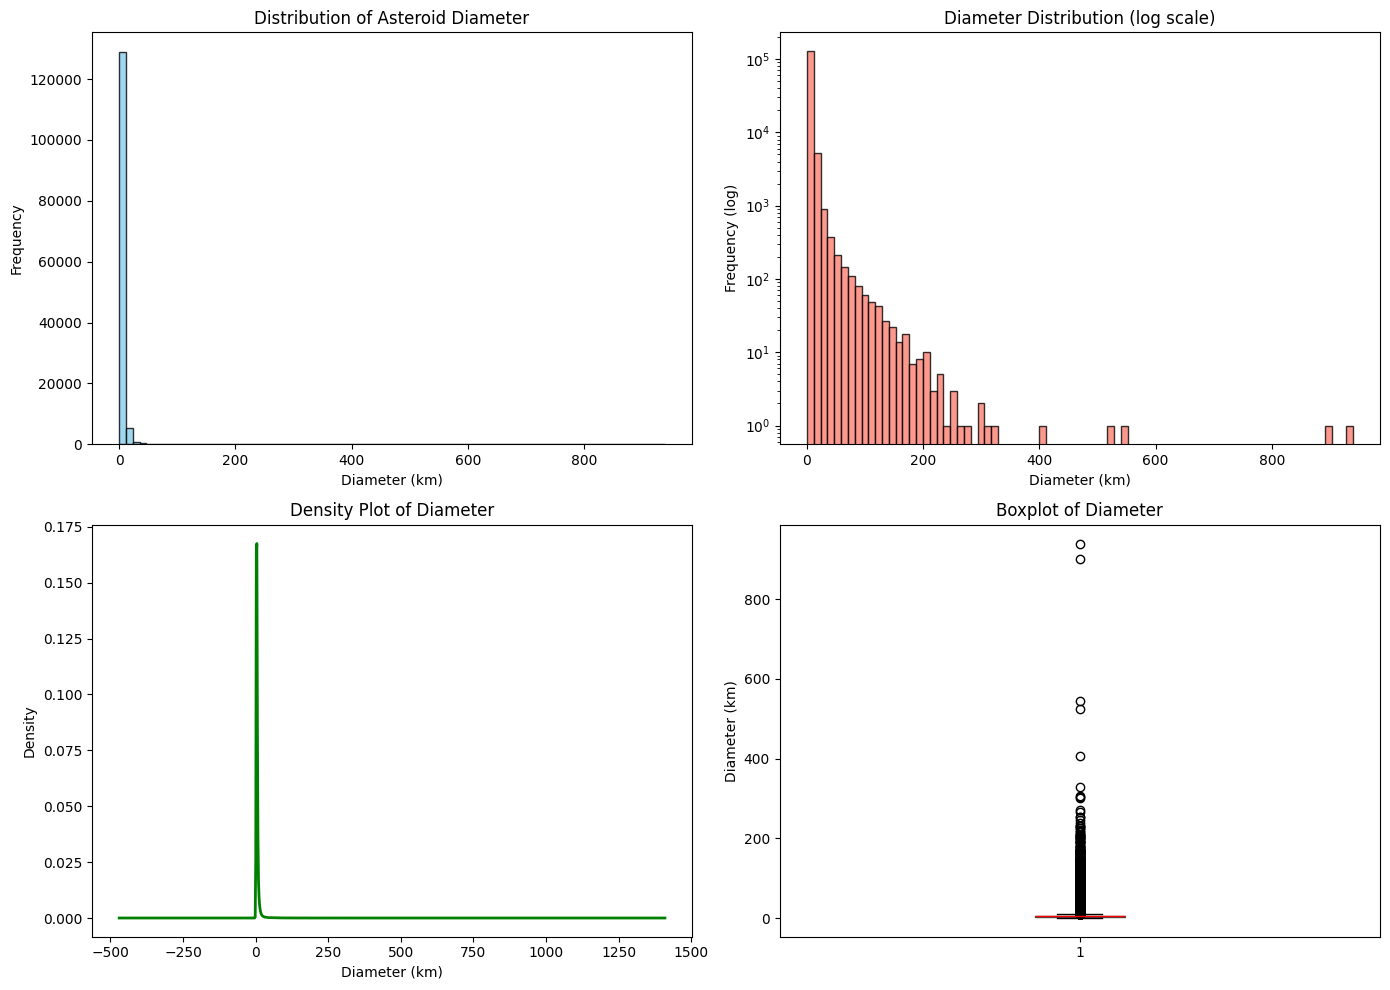

In [12]:
# Diameter distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_diameter['diameter'], bins=80, edgecolor='black', color='skyblue', alpha=0.8)
axes[0, 0].set_title('Distribution of Asteroid Diameter')
axes[0, 0].set_xlabel('Diameter (km)')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(df_diameter['diameter'], bins=80, edgecolor='black', color='salmon', alpha=0.8)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Diameter Distribution (log scale)')
axes[0, 1].set_xlabel('Diameter (km)')
axes[0, 1].set_ylabel('Frequency (log)')

df_diameter['diameter'].plot(kind='density', ax=axes[1, 0], color='green', lw=2)
axes[1, 0].set_title('Density Plot of Diameter')
axes[1, 0].set_xlabel('Diameter (km)')
axes[1, 0].set_ylabel('Density')

axes[1, 1].boxplot(df_diameter['diameter'], patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red'))
axes[1, 1].set_title('Boxplot of Diameter')
axes[1, 1].set_ylabel('Diameter (km)')

plt.tight_layout()
plt.show()

In [13]:
# Key features to analyze with diameter
selected_features = ['H', 'albedo', 'a', 'e', 'i', 'diameter']
subset = df_asteroid[selected_features].dropna()

subset.head()

,H,albedo,a,e,i,diameter
0,3.40,0.0900,2.769165,0.076009,10.594067,939.400
1,4.20,0.1010,2.773841,0.229972,34.832932,545.000
2,5.33,0.2140,2.668285,0.256936,12.991043,246.596
3,3.00,0.4228,2.361418,0.088721,7.141771,525.400
4,6.90,0.2740,2.574037,0.190913,5.367427,106.699


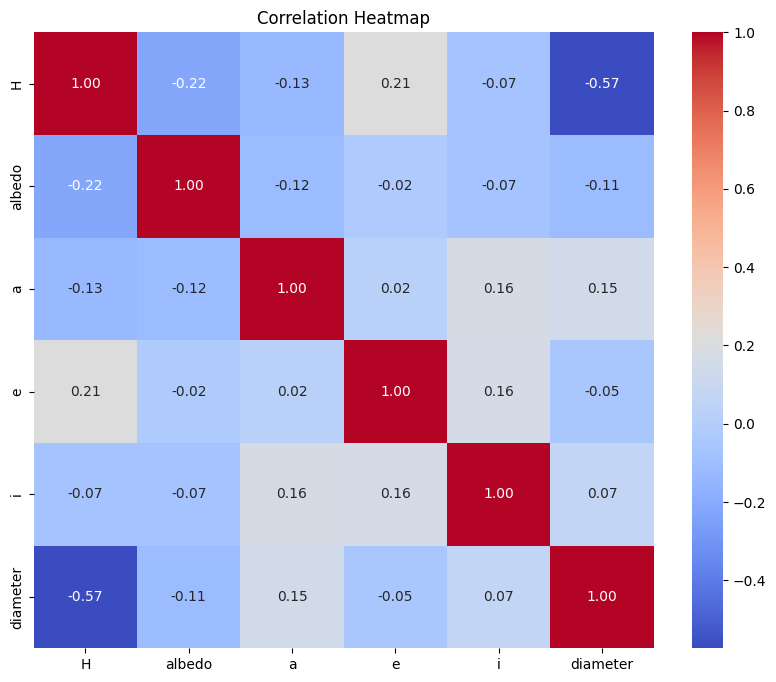

In [14]:
# Correlation heatmap
corr = subset.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

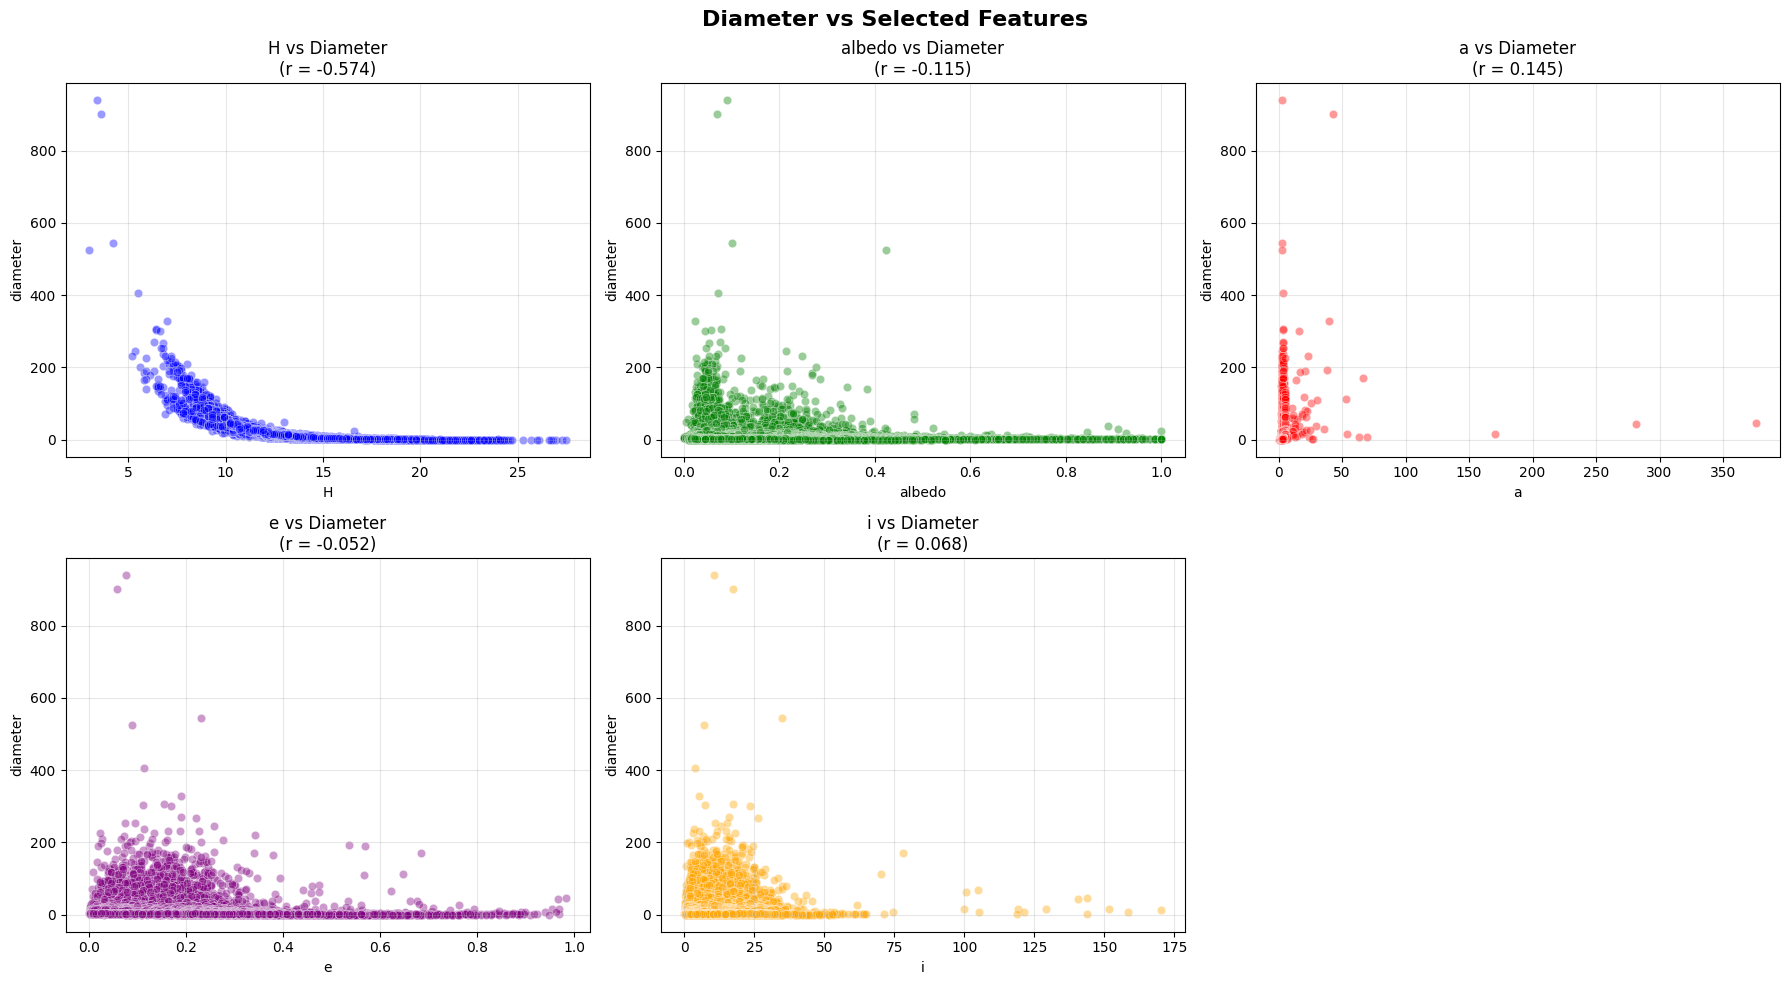

In [15]:
# Scatterplots: diameter vs selected features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Diameter vs Selected Features', fontsize=16, fontweight='bold')

feature_list = ['H', 'albedo', 'a', 'e', 'i']
colors = ['blue', 'green', 'red', 'purple', 'orange']

for i, feature in enumerate(feature_list):
    row, col = divmod(i, 3)
    ax = axes[row, col]
    sns.scatterplot(data=subset, x=feature, y='diameter', alpha=0.4, color=colors[i], ax=ax)
    corr_val = subset[[feature, 'diameter']].corr().iloc[0, 1]
    ax.set_title(f'{feature} vs Diameter\n(r = {corr_val:.3f})')
    ax.grid(True, alpha=0.3)

# Hide empty subplot if present
if len(feature_list) < 6:
    axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

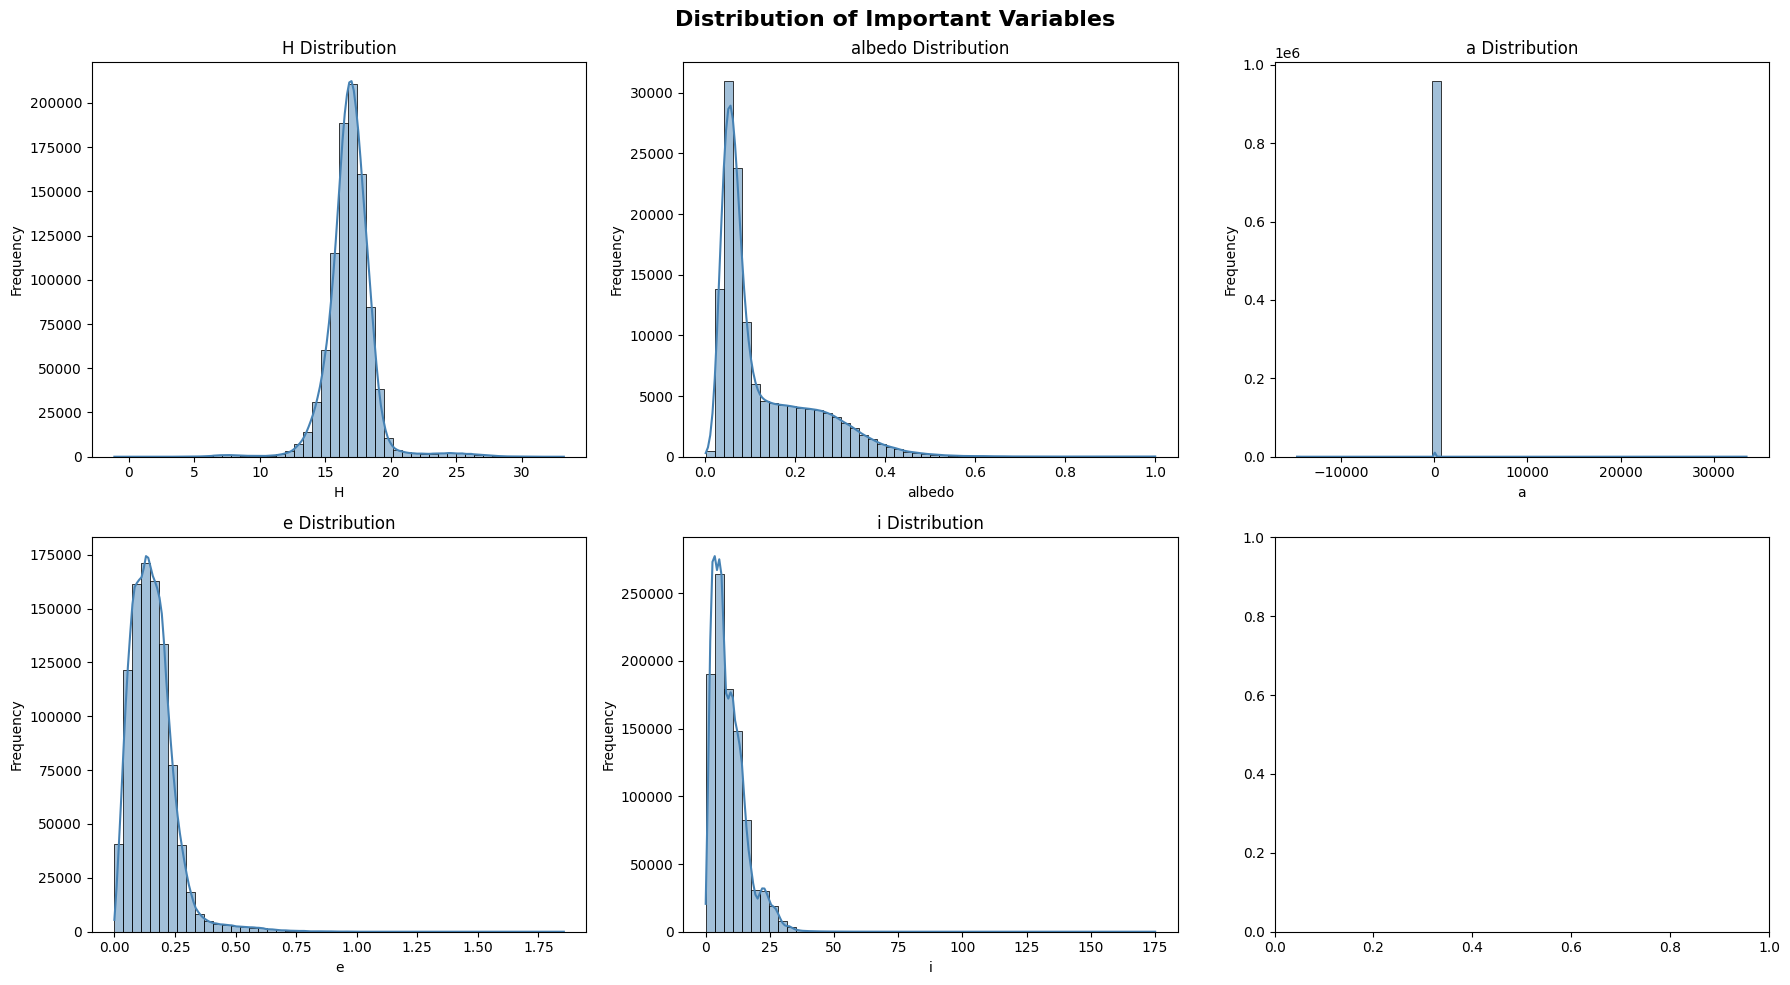

In [16]:
# Distribution of important variables
important_vars = ['H', 'albedo', 'a', 'e', 'i']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Important Variables', fontsize=16, fontweight='bold')

for i, var in enumerate(important_vars):
    row, col = divmod(i, 3)
    sns.histplot(df_asteroid[var].dropna(), bins=50, kde=True, ax=axes[row, col], color='steelblue')
    axes[row, col].set_title(f'{var} Distribution')
    axes[row, col].set_xlabel(var)
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

diameter_category
<1 km          611
1-5 km       89761
5-10 km      35731
10-50 km      9343
50-100 km      523
>100 km        240
Name: count, dtype: int64


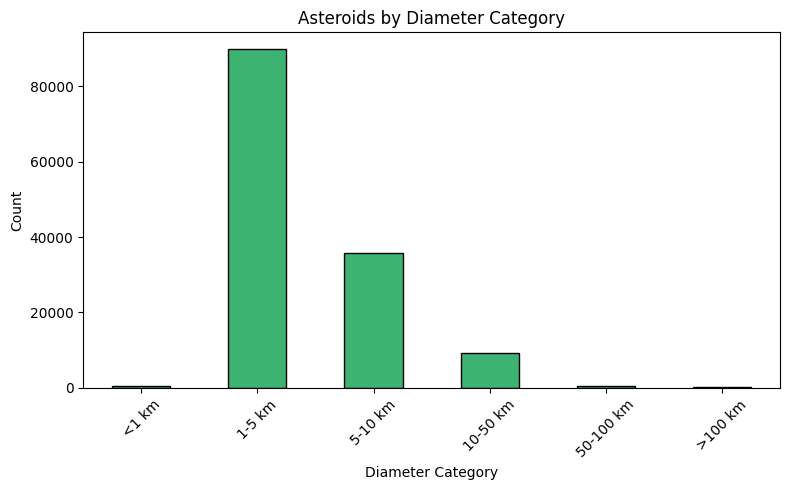

In [17]:
# Optional: diameter categories
bins = [0, 1, 5, 10, 50, 100, 1000]
labels = ['<1 km', '1-5 km', '5-10 km', '10-50 km', '50-100 km', '>100 km']

df_diameter['diameter_category'] = pd.cut(df_diameter['diameter'], bins=bins, labels=labels, right=False)

category_counts = df_diameter['diameter_category'].value_counts().sort_index()
print(category_counts)

plt.figure(figsize=(8, 5))
category_counts.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Asteroids by Diameter Category')
plt.xlabel('Diameter Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# Summary of correlations with diameter
corr_with_diameter = subset.corr()['diameter'].drop('diameter').sort_values(ascending=False)
print(corr_with_diameter)

a         0.145010
i         0.067686
e        -0.052382
albedo   -0.114903
H        -0.573641
Name: diameter, dtype: float64


# Task 1

In [19]:
## Question 1

# No, based on the visuals, the target variable “diameter” is not normally distributed.
# It is strongly right-skewed, and a log transformation would make it
# much closer to a normal distribution for modeling purposes.

# The clearest visual evidence is the histogram and Q-Q plot:

# The diameter histogram is strongly right-skewed: most asteroid diameters are concentrated at small values,
# while a long tail extends toward very large diameters.

# The Q-Q plot bends away from the straight reference line, especially in the tails. For a normal distribution,
# the points should stay close to that line.

# The density curve is asymmetric and heavier on the right side, which is another sign of skewness.

# The boxplot shows many outliers above the upper whisker, which is typical of a skewed distribution rather than a normal one.

# This pattern is expected in asteroid datasets because there are many small asteroids and only a few unusually large ones.
# In other words, a small number of very large diameters creates a long right tail.


In [20]:
# Question 2

# The strongest relationships with asteroid diameter appear to be:

# Absolute magnitude (H): strong negative relationship—larger asteroids generally have lower H values.
# Albedo: a weaker relationship compared with H.
# Orbital features such as semi-major axis (a), eccentricity (e), and inclination (i)
# show relatively weak relationships with diameter.

In [21]:
# Question 3

# Absolute magnitude (H) remains the strongest predictor, which is fundamentally a
# brightness measurement—more directly related to the physical size and reflectivity of the asteroid.

# Orbital characteristics might influence asteroid size for these reasons:

# Collisional History: Asteroids in different orbital regions experience different collision frequencies and impacts.
# Asteroids in crowded regions (like the inner asteroid belt) undergo more collisions,
# which can fragment larger asteroids into smaller pieces over time.

# Dynamical Stability: Stable orbits allow asteroids to survive longer without being ejected or colliding.
# Asteroids in unstable orbits may be destroyed, leaving only smaller remnants or newly formed small asteroids.

# Migration and Orbital Resonances: Orbital resonances with planets can cause asteroids to migrate into different regions.
# Some regions may be more conducive to retaining larger bodies, while others may preferentially contain smaller asteroids.

# Formation Location: Asteroids formed at different distances from the Sun had different formation conditions
# (temperature, material composition, density). These formation locations correlate with current orbital characteristics,
# which may influence typical asteroid sizes in those regions.

# Compositional Variation by Orbit: Different orbital zones contain asteroids of different compositions
# (C-type, S-type, M-type, etc.). Some compositions may naturally produce larger bodies, or larger bodies of
# certain compositions may survive longer in specific orbits.

# Gravitational Interactions: Close encounters with planets or larger asteroids can alter orbits.
# The orbital characteristics reflect the dynamical history, which is tied to size distribution outcomes.

# However, the weak correlation observed in your data suggests these orbital factors are not primary drivers of asteroid size.


# Data Preprocessing & Feature Engineering

In [22]:
# Features: orbital and physical properties
# Target: diameter

# Exclude identifier columns and other non-feature columns.
# 'neo', 'pha', and 'class' are intended as features after encoding, so they are not in this exclude list.
exclude_cols = ['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix',
                     'orbit_id', 'equinox', 'epoch_cal']

In [23]:
# Encode neo and pha (binary Y/N columns)
df_asteroid['neo'] = df_asteroid['neo'].map({'Y': 1, 'N': 0})
df_asteroid['pha'] = df_asteroid['pha'].map({'Y': 1, 'N': 0})

In [24]:
# One-hot encode class
df_asteroid = pd.get_dummies(df_asteroid, columns=['class'], drop_first=True)

In [25]:
# First, check what columns exist
print(df_asteroid.columns)

# Check which columns are categorical (object type)
print(df_asteroid.dtypes)

# See unique values in categorical columns
print(df_asteroid.select_dtypes(include='object').head())

Index(['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'H',
       'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch',
       'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w',
       'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms',
       'class_APO', 'class_AST', 'class_ATE', 'class_CEN', 'class_HYA',
       'class_IEO', 'class_IMB', 'class_MBA', 'class_MCA', 'class_OMB',
       'class_TJN', 'class_TNO'],
      dtype='object')
id                 object
spkid               int64
full_name          object
pdes               object
name               object
prefix             object
neo               float64
pha               float64
H                 float64
diameter          float64
albedo            float64
diameter_sigma    float64
orbit_id           object
epoch           

In [26]:
# Drop excluded columns from dataframe

df_asteroid.drop(columns=exclude_cols, inplace=True)

In [27]:
## Separating Numerical and Categorical data
numeric_cols = df_asteroid.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_asteroid.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# show dtypes for manual checking
print("\nColumn dtypes:\n", df_asteroid.dtypes)

Numeric columns: ['neo', 'pha', 'H', 'diameter', 'albedo', 'diameter_sigma', 'epoch', 'epoch_mjd', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms']
Categorical columns: ['class_APO', 'class_AST', 'class_ATE', 'class_CEN', 'class_HYA', 'class_IEO', 'class_IMB', 'class_MBA', 'class_MCA', 'class_OMB', 'class_TJN', 'class_TNO']

Column dtypes:
 neo               float64
pha               float64
H                 float64
diameter          float64
albedo            float64
diameter_sigma    float64
epoch             float64
epoch_mjd           int64
e                 float64
a                 float64
q                 float64
i                 float64
om                float64
w                 float64
ma                float64
ad                float64
n                 float64
tp                float64
tp_ca

In [29]:
df_asteroid.head(5)

,neo,pha,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,e,a,...,class_ATE,class_CEN,class_HYA,class_IEO,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
0,0.0,0.0,3.40,939.400,0.0900,0.200,2458600.5,58600,0.076009,2.769165,...,False,False,False,False,False,True,False,False,False,False
1,0.0,0.0,4.20,545.000,0.1010,18.000,2459000.5,59000,0.229972,2.773841,...,False,False,False,False,False,True,False,False,False,False
2,0.0,0.0,5.33,246.596,0.2140,10.594,2459000.5,59000,0.256936,2.668285,...,False,False,False,False,False,True,False,False,False,False
3,0.0,0.0,3.00,525.400,0.4228,0.200,2458600.5,58600,0.088721,2.361418,...,False,False,False,False,False,True,False,False,False,False
4,0.0,0.0,6.90,106.699,0.2740,3.140,2459000.5,59000,0.190913,2.574037,...,False,False,False,False,False,True,False,False,False,False


In [31]:
# Remove rows with missing values in key columns
df_clean = df_asteroid.dropna()

print(f"Original dataset: {len(df_asteroid):,} rows")
print(f"After removing missing values: {len(df_clean):,} rows")
print(f"Rows removed: {len(df_asteroid) - len(df_clean):,}")
print(f"Data retention: {len(df_clean)/len(df_asteroid)*100:.2f}%")

# Check remaining missing values
print("\nMissing values after cleaning:")
print(df_clean.isna().sum().sum())

Original dataset: 958,524 rows
After removing missing values: 0 rows
Rows removed: 958,524
Data retention: 0.00%

Missing values after cleaning:
0


In [32]:
df_asteroid.isna().sum()

,0
id,0
spkid,0
full_name,0
pdes,0
name,936460
prefix,958506
neo,4
pha,19921
H,6263
diameter,822315


# Train-Test Split

In [33]:
X = df_asteroid.drop(columns=['diameter'])      # Feature
y = df_asteroid['diameter']                     # Target

In [34]:
# Split the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (766819, 44)
Testing : (191705, 44)


## Scaling

In [35]:
X_train.select_dtypes(include='object').columns


Index(['id', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'orbit_id',
       'equinox', 'class'],
      dtype='object')

In [62]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ValueError: could not convert string to float: 'a0307414'

In [ ]:
y = y.fillna(0)

In [ ]:
# Calculate feature importance

print("="*70)
print("STEP 5: Feature Importance (Random Forest)")
print("="*70)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=20)
rf_model.fit(X, y)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance Ranking:")
for idx, row in feature_importance.iterrows():
    bar = '█' * int(row['importance'] * 100)
    print(f"{row['feature']:25s}: {row['importance']:7.4f} {bar}")

print("\nTop 10 Most Important Features:")
for i, (idx, row) in enumerate(feature_importance.head(10).iterrows(), 1):
    print(f"{i:2d}. {row['feature']:25s} (importance: {row['importance']:.4f})")

In [ ]:
# Visualize feature importance

fig, ax = plt.subplots(figsize=(12, 8))

top_20 = feature_importance.head(20)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_20)))
ax.barh(range(len(top_20)), top_20['importance'].values, color=colors)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'].values, fontsize=10)
ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Most Important Features for Diameter Prediction',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(top_20['importance'].values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Task 2

In [ ]:
# Question 1

# Feature scaling is important for DNNs because:

# Faster convergence - Gradient descent updates weights more efficiently
# Prevents vanishing/exploding gradients - Keeps values in safe numerical ranges
# Equal feature contribution - Large-range features don't dominate learning
# One learning rate for all features - Simplifies hyperparameter tuning
# Better weight initialization - Aligns with how weights are initialized
# Fairer regularization - L1/L2 penalties applied equally across features

In [ ]:
# Question 2

# Features Removed:

# Identifiers (7 columns): id, spkid, full_name, pdes, name, prefix, orbit_id

# Why: Non-predictive metadata, no relationship to diameter
# Target Variable (1 column): diameter

# Why: Cannot use target as input feature
# Measurement Uncertainty (1 column): diameter_sigma

# Why: Correlates with data availability, not actual diameter; adds noise
# Redundant Time Variables (3 columns): epoch, epoch_cal, tp_cal

# Why: Epoch_mjd kept; these are duplicate time representations
# Derived Orbital Elements (2 columns): per, per_y

# Why: Orbital period is derived from semi-major axis (a); redundant
# Measurement Noise/Sigma Columns (11 columns): sigma_e, sigma_a, sigma_q,
# sigma_i, sigma_om, sigma_w, sigma_ma, sigma_ad, sigma_n, sigma_tp, sigma_per

# Why: Measurement errors, not predictive features; add noise without
# predictive power
# Total Removed: 25 columns

# Retained: 32 features (H, albedo, orbital elements, neo, pha, moid,
# class encodings, rms, equinox)

In [ ]:
# Qusetion 3

# How Highly Correlated Features Affect Model Learning:

# Multicollinearity Issues

# Weights become unstable and unreliable
# Small changes in data cause large weight swings
# Model becomes fragile and doesn't generalize well
# Redundant Information

# Same information encoded twice wastes model capacity
# Neural network uses extra layers/neurons for correlated features
# Inefficient use of computational resources
# Difficulty in Feature Importance

# Can't determine which correlated feature truly drives predictions
# Feature importance scores become ambiguous
# Hard to interpret model decisions
# Slower Convergence

# Gradient descent takes longer to optimize weights
# Creates a flat valley in the loss surface
# Training becomes slower and less stable
# Overfitting Risk

# Model fits noise in one correlated feature
# Poor generalization to new data
# Validation performance drops
# Regularization Less Effective

# L1/L2 penalties can't efficiently reduce correlated features
# Regularization may remove useful information instead
# Example: If you have both a (semi-major axis) and per (orbital period) —
# they're mathematically related (Kepler's law). Using both is redundant.

## DNN

In [ ]:
# HYPERPARAMETERS

lr = 0.001  # Learning rate
batch_size = 32  # Batch size
num_neurons = 128  # Number of neurons
dropout_rate = 0.3  # Dropout rate
epochs = 5

print("\n" + "="*70)
print("HYPERPARAMETERS")
print("="*70)
print(f"Learning Rate: {lr}")
print(f"Batch Size: {batch_size}")
print(f"Number of Neurons: {num_neurons}")
print(f"Dropout Rate: {dropout_rate}")

In [ ]:
# BUILD DNN MODEL

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.20),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.20),

    layers.Dense(32, activation='relu'),

    layers.Dense(1, activation='linear')
])

In [ ]:
# Compile model

optimizer = Adam(learning_rate=lr)
model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae', 'mse']
)

print("\n" + "="*70)
print("MODEL ARCHITECTURE")
print("="*70)
model.summary()

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=[
        'mae'
    ]
)

In [ ]:
# TRAIN MODEL

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("Training completed!")

In [ ]:
# PLOT TRAINING HISTORY
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('DNN Training Performance: Loss and MAE', fontsize=14, fontweight='bold')

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
axes[0].set_title('Training vs Validation Loss', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# MAE plot
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2, color='green')
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2, color='orange')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE (km)', fontsize=12, fontweight='bold')
axes[1].set_title('Training vs Validation MAE', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Task 3

In [ ]:
# Question 1

# MOdel Evaluation & Error Analysis

In [ ]:
y_pred = model.predict(X_test).flatten()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)
plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('DNN Training vs Validation Loss')

plt.legend()
plt.show()


In [ ]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel('Actual Diameter')
plt.ylabel('Predicted Diameter')
plt.title('Actual vs Predicted Asteroid Diameter')

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--'
)

plt.show()


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


In [ ]:
y_pred = model.predict(X_test).flatten()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)


In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('DNN Training vs Validation Loss')

plt.legend()
plt.show()


In [ ]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel('Actual Diameter')
plt.ylabel('Predicted Diameter')
plt.title('Actual vs Predicted Asteroid Diameter')

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--'
)

plt.show()


In [ ]:
# PLOT PREDICTIONS VS ACTUAL

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Predictions vs Actual Values', fontsize=14, fontweight='bold')

# Training
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=20, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Diameter (km)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Predicted Diameter (km)', fontsize=11, fontweight='bold')
axes[0].set_title(f'Training Set (R² = {train_r2:.4f})', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Validation
axes[1].scatter(y_val, y_val_pred, alpha=0.5, s=20, color='green')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Diameter (km)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Predicted Diameter (km)', fontsize=11, fontweight='bold')
axes[1].set_title(f'Validation Set (R² = {val_r2:.4f})', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

# Test
axes[2].scatter(y_test, y_test_pred, alpha=0.5, s=20, color='orange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual Diameter (km)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Predicted Diameter (km)', fontsize=11, fontweight='bold')
axes[2].set_title(f'Test Set (R² = {test_r2:.4f})', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# SUMMARY

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"\nHyperparameters Used:")
print(f"  Learning Rate: {lr}")
print(f"  Batch Size: {batch_size}")
print(f"  Number of Neurons: {num_neurons}")
print(f"  Dropout Rate: {dropout_rate}")

print(f"\nModel Architecture:")
print(f"  Input: {X_train_scaled.shape[1]} features")
print(f"  Hidden: 3 × {num_neurons} neurons with ReLU + {dropout_rate*100}% Dropout")
print(f"  Output: 1 neuron (Linear)")
print(f"  Total Parameters: {model.count_params():,}")

print(f"\nBest Performance:")
print(f"  Best Val MSE: {min(history.history['val_loss']):.4f}")
print(f"  Best Val MAE: {min(history.history['val_mae']):.4f} km")

print(f"\nTest Set Results:")
print(f"  RMSE: {test_rmse:.4f} km")
print(f"  MAE:  {test_mae:.4f} km")
print(f"  R²:   {test_r2:.4f}")

print("="*70)